In [1]:
import copy
import gc
import torch
import sympy
from kan import *

In [2]:
gc.collect()

0

# 无监督学习
本实验尝试解决一个无监督关系发现问题。数据集含 7 个变量，并满足：
- $x_2=\sin(6x_0)+e^{2x_1}$
- $x_6=4x_3+x_4+x_5$

KAN 需要仅凭变量取值自动识别这些关系。

## 怎么推进更合适？
如果把变量划分为“自变量/因变量”，问题会退化为监督学习；但这样需要穷举 $2^7-2$ 个候选任务，计算代价很高。  
论文采用了更高效的方案：
1. 真实样本统一标记为 1。
2. 构造“污染样本”并标记为 0。做法是随机打乱各特征，尽量不破坏原数据拓扑。
3. 在该二分类式数据上做回归建模。

## 如何理解最终函数？
理想上我们先得到：
$$
g:\begin{cases}
g(x_{\text{real}})=1\\
g(x_{\text{fake}})=0
\end{cases}
$$

而真正关心的形式是：
$$
f:\begin{cases}
f(x_{\text{real}})=0\\
f(x_{\text{fake}})\neq 0
\end{cases}
$$

因此在末端额外加入一层固定高斯映射
$\sigma(x)=e^{-\frac{x^2}{2\omega^2}}$（$\omega$ 很小），使得 $g=\sigma\circ f$。

In [3]:
def create_dataset(train_num=1000, test_num=500):
    def generate_contrastive(x):
        # positive samples
        batch = x.shape[0]
        x[:, 2] = torch.sin(6 * x[:, 0]) + torch.exp(2 * x[:, 1])
        x[:, 6] = 4 * x[:, 3] + x[:, 4] + x[:, 5]

        # negative samples
        x_cor = copy.deepcopy(x)
        for i in range(x_cor.shape[1]):
            x_cor[:, i] = x_cor[:, i][torch.randperm(x_cor.shape[0])]

        inputs = torch.cat([x, x_cor], dim=0)
        labels = torch.cat([torch.ones(batch, ), torch.zeros(batch, )], dim=0)[:, None]
        return inputs, labels

    x = torch.rand(train_num, 7) * 2 - 1
    x_train, y_train = generate_contrastive(x)

    x = torch.rand(test_num, 7) * 2 - 1
    x_test, y_test = generate_contrastive(x)

    dataset = {'train_input': x_train, 'test_input': x_test, 'train_label': y_train, 'test_label': y_test}
    return dataset


dataset = create_dataset()

# 第一条关系
在大多数随机种子下，模型都能较快找到
$f(x_3,x_4,x_5,x_6)=4x_3+x_4+x_5-x_6=0$。

当损失明显下降时，通常说明模型确实学到了有效结构；同时正则项会限制总损失继续无限下降。

In [4]:
model = KAN(width=[7, 1, 1], grid=3, k=3)
model.fix_symbolic(1, 0, 0, 'gaussian', fit_params_bool=False)

checkpoint directory created: ./model
saving model version 0.0
saving model version 0.1


| train_loss: 2.00e-01 | test_loss: 1.92e-01 | reg: 5.84e+00 | : 100%|█| 30/30 [00:11<00:00,  2.67it


saving model version 0.2


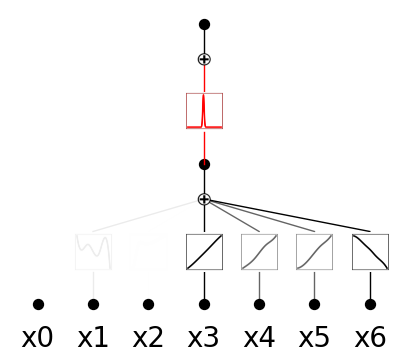

In [5]:
model.fit(dataset, opt="LBFGS", steps=30, lamb=0.01, lamb_entropy=4.0)
model.plot(in_vars=['x0','x1','x2','x3','x4','x5','x6'], scale=.5)

saving model version 0.3


| train_loss: 8.87e-02 | test_loss: 8.08e-02 | reg: 6.50e+00 | : 100%|█| 30/30 [00:08<00:00,  3.35it


saving model version 0.4


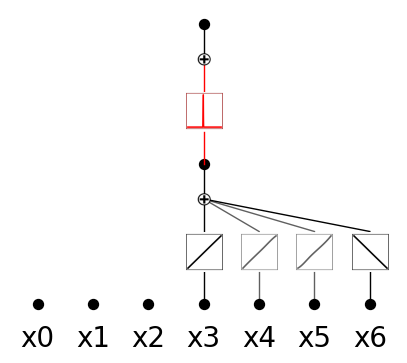

In [6]:
model.prune_edge()
model.fit(dataset, steps=30)
model.plot(in_vars=['x0','x1','x2','x3','x4','x5','x6'], scale=.5)

fixing (0,0,0) with 0
fixing (0,1,0) with 0
fixing (0,2,0) with 0
fixing (0,3,0) with x, r2=0.9999957084655762, c=1
fixing (0,4,0) with x, r2=0.9998914003372192, c=1
fixing (0,5,0) with x, r2=0.999464213848114, c=1
fixing (0,6,0) with x, r2=0.9999949932098389, c=1
skipping (1,0,0) since already symbolic
saving model version 0.5


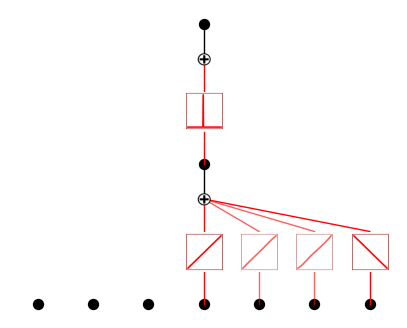

In [7]:
model.auto_symbolic()
model.plot()

In [8]:
model.fit(dataset, steps=20);

| train_loss: 1.09e-03 | test_loss: 2.36e-02 | reg: 0.00e+00 | : 100%|█| 20/20 [00:06<00:00,  3.20it

saving model version 0.6


In [9]:
formula = model.symbolic_formula()[0][0]
ex_round(formula,3)

1.051*exp(-952386.959*(x_4 + 0.25*x_5 + 0.25*x_6 - 0.25*x_7)**2)

# 第二条关系
为了得到另一条关系，可以不断更换随机种子，这也是论文中的标准做法。

但由于
$f(x_0,x_1,x_2)=sin(6x_0)+e^{2x_1}-x_2=0$
更难被直接发现，我们可以利用先验“不同关系变量不重叠”：先关闭 $x_3,x_4,x_5,x_6$ 相关边，再从头训练 KAN。

checkpoint directory created: ./model
saving model version 0.0
saving model version 0.1
saving model version 0.2
saving model version 0.3
saving model version 0.4
saving model version 0.5


| train_loss: 1.97e-01 | test_loss: 1.93e-01 | reg: 9.87e+00 | : 100%|█| 40/40 [00:15<00:00,  2.58it


saving model version 0.6


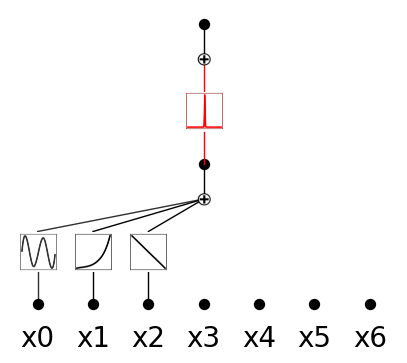

In [10]:
model2 = KAN(width=[7, 1, 1], grid=3, k=3)
model2.fix_symbolic(1, 0, 0, 'gaussian', fit_params_bool=False)
for l, i, j in [(0, 3, 0), (0, 4, 0), (0, 5, 0), (0, 6, 0)]:
    model2.fix_symbolic(l, i, j, '0', fit_params_bool=False)
model2.fit(dataset, opt="LBFGS", steps=40, lamb=0.0001, lamb_entropy=4.0)
model2.plot(in_vars=['x0','x1','x2','x3','x4','x5','x6'], scale=.5)


In [11]:
model2.prune_edge()
model2.fit(dataset,steps=20);

saving model version 0.7


| train_loss: 1.94e-01 | test_loss: 1.96e-01 | reg: 6.87e+00 | : 100%|█| 20/20 [00:05<00:00,  3.74it

saving model version 0.8


In [12]:
model2.suggest_symbolic(0,0,0)

  function  fitting r2   r2 loss  complexity  complexity loss  total loss
0        0    0.000000  0.000014           0                0    0.000003
1      sin    0.988986 -6.503164           2                2    0.299367
2      cos    0.988986 -6.503148           2                2    0.299370
3        x    0.155419 -0.243676           1                1    0.751265
4      exp    0.169549 -0.268015           2                2    1.546397


('0',
 (<function kan.utils.<lambda>(x)>,
  <function kan.utils.<lambda>(x)>,
  0,
  <function kan.utils.<lambda>(x, y_th)>),
 0.0,
 0)

In [13]:
model2.fix_symbolic(0,0,0,'sin')

r2 is 0.9889856576919556
saving model version 0.9


tensor(0.9890)

skipping (0,0,0) since already symbolic
fixing (0,1,0) with exp, r2=0.9999908804893494, c=2
fixing (0,2,0) with x, r2=0.9999476075172424, c=1
skipping (0,3,0) since already symbolic
skipping (0,4,0) since already symbolic
skipping (0,5,0) since already symbolic
skipping (0,6,0) since already symbolic
skipping (1,0,0) since already symbolic
saving model version 0.10


| train_loss: 3.89e-03 | test_loss: 1.73e-02 | reg: 0.00e+00 | : 100%|█| 20/20 [00:06<00:00,  3.13it


saving model version 0.11


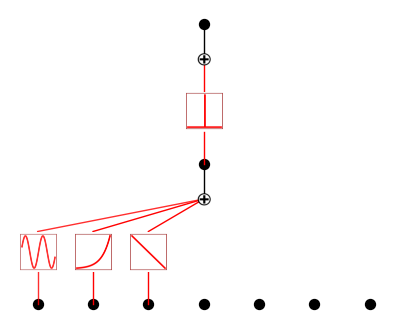

In [14]:
model2.auto_symbolic()
model2.fit(dataset,steps=20);
model2.plot()

In [15]:
formula2 = model2.symbolic_formula()[0][0]
ex_round(formula2,4)

-0.0009 + 1.0021*exp(-25035.7677*(-1.0*x_3 + 0.9998*exp(2.0002*x_2) + sin(5.9999*x_1 - 0.e-4) - 0.0002)**2)